# 02 Preprocessing

This notebook turns the scoped single-family residential sales data into a clean modeling dataset for the baseline model. It follows the same core filters used in `01_exploration.ipynb`, then adds missing-value handling, feature selection, and the required time-based train/test split.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.2f}".format)
plt.style.use("ggplot")


In [2]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

eda_base_path = processed_dir / "eda_scoped_base.csv"

if eda_base_path.exists():
    base_df = pd.read_csv(
        eda_base_path, parse_dates=["CloseDate", "source_month", "close_month"]
    )
    print(f"Loaded Week 1 scoped dataset from {eda_base_path}")
    print(f"Base shape: {base_df.shape}")
else:
    raw_dir = Path("../data/raw")
    raw_files = sorted(raw_dir.glob("CRMLSSold*.csv"))
    if not raw_files:
        raise FileNotFoundError("No raw CSV files were found in ../data/raw")

    frames = []
    for file_path in raw_files:
        month_tag = file_path.stem.replace("CRMLSSold", "")
        monthly_df = pd.read_csv(file_path, low_memory=False)
        monthly_df["source_file"] = file_path.name
        monthly_df["source_month"] = month_tag
        frames.append(monthly_df)

    raw_df = pd.concat(frames, ignore_index=True)

    print(f"Loaded {len(raw_files)} monthly files")
    print(f"Raw shape: {raw_df.shape}")
    display(pd.DataFrame({"file": [p.name for p in raw_files]}))


Loaded Week 1 scoped dataset from ../data/processed/eda_scoped_base.csv
Base shape: (71414, 85)


In [3]:
if "base_df" not in globals():
    scoped_df = raw_df.loc[
        (raw_df["PropertyType"] == "Residential")
        & (raw_df["PropertySubType"] == "SingleFamilyResidence")
    ].copy()

    scoped_df["dedupe_key"] = (
        scoped_df["ListingKeyNumeric"].astype("string").fillna("").str.strip()
    )

    missing_dedupe_key = scoped_df["dedupe_key"].eq("")
    scoped_df.loc[missing_dedupe_key, "dedupe_key"] = (
        scoped_df.loc[missing_dedupe_key, "ListingId"]
        .astype("string")
        .fillna("")
        .str.strip()
    )

    still_missing_dedupe_key = scoped_df["dedupe_key"].eq("")
    scoped_df.loc[still_missing_dedupe_key, "dedupe_key"] = (
        scoped_df.loc[still_missing_dedupe_key, "ListingKey"]
        .astype("string")
        .fillna("")
        .str.strip()
    )

    base_df = scoped_df.drop_duplicates(subset="dedupe_key", keep="first").copy()

    numeric_cols = [
        "ClosePrice",
        "ListPrice",
        "LivingArea",
        "BedroomsTotal",
        "BathroomsTotalInteger",
        "LotSizeSquareFeet",
        "YearBuilt",
        "Latitude",
        "Longitude",
        "DaysOnMarket",
    ]

    for col in numeric_cols:
        if col in base_df.columns:
            base_df[col] = pd.to_numeric(base_df[col], errors="coerce")

    base_df["CloseDate"] = pd.to_datetime(base_df["CloseDate"], errors="coerce")
    base_df["source_month"] = pd.to_datetime(
        base_df["source_month"], format="%Y%m", errors="coerce"
    )
    base_df["close_month"] = base_df["CloseDate"].dt.to_period("M").dt.to_timestamp()

print(f"Rows in preprocessing base: {len(base_df):,}")
print(f"Unique close months: {base_df['close_month'].nunique(dropna=True)}")


Rows in preprocessing base: 71,414
Unique close months: 7


In [4]:
model_df = base_df.copy()

model_df = model_df.loc[model_df["ClosePrice"] > 1000].copy()
model_df = model_df.loc[model_df["ListPrice"] > 0].copy()
model_df = model_df.loc[model_df["LivingArea"] > 300].copy()
model_df = model_df.loc[model_df["CloseDate"].notna()].copy()

model_df.loc[model_df["DaysOnMarket"] < 0, "DaysOnMarket"] = np.nan
model_df.loc[model_df["LotSizeSquareFeet"] <= 0, "LotSizeSquareFeet"] = np.nan
model_df.loc[model_df["YearBuilt"] < 1900, "YearBuilt"] = np.nan

model_df["property_age"] = model_df["CloseDate"].dt.year - model_df["YearBuilt"]
model_df["property_age"] = model_df["property_age"].where(model_df["property_age"] >= 0)
model_df["log_living_area"] = np.log1p(model_df["LivingArea"])
model_df["bathrooms_per_bedroom"] = model_df["BathroomsTotalInteger"] / model_df[
    "BedroomsTotal"
].replace({0: np.nan})

feature_cols = [
    "ListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "DaysOnMarket",
    "property_age",
    "log_living_area",
    "bathrooms_per_bedroom",
    "CountyOrParish",
]

model_df = model_df[["ClosePrice", "CloseDate", "close_month"] + feature_cols].copy()

print(f"Rows after week 3 cleaning: {len(model_df):,}")
print(f"Columns kept for modeling: {len(feature_cols)}")
display(model_df.head())


Rows after week 3 cleaning: 71,352
Columns kept for modeling: 13


,ClosePrice,CloseDate,close_month,ListPrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,Latitude,Longitude,DaysOnMarket,property_age,log_living_area,bathrooms_per_bedroom,CountyOrParish
0,1250000.00,2025-11-30,2025-11-01,1250000.00,1027.00,3.00,2.00,5913.00,1961.00,33.68,-118.00,0.00,64.00,6.94,0.67,Orange
1,2299995.00,2025-11-20,2025-11-01,2299995.00,1129.00,3.00,1.00,18432.00,1949.00,37.26,-121.93,0.00,76.00,7.03,0.33,Santa Clara
2,810000.00,2025-11-26,2025-11-01,799900.00,1619.00,4.00,3.00,5300.00,1978.00,32.56,-117.06,0.00,47.00,7.39,0.75,San Diego
3,925000.00,2025-11-17,2025-11-01,925000.00,2872.00,5.00,3.00,5272.00,2000.00,32.58,-117.02,0.00,25.00,7.96,0.60,San Diego
4,1300000.00,2025-11-25,2025-11-01,1300000.00,1727.00,3.00,2.00,10500.00,1950.00,35.55,-120.71,0.00,75.00,7.45,0.67,San Luis Obispo


,column,missing_pct
7,LotSizeSquareFeet,0.02
12,property_age,0.00
8,YearBuilt,0.00
14,bathrooms_per_bedroom,0.00
9,Latitude,0.00
10,Longitude,0.00
11,DaysOnMarket,0.00
6,BathroomsTotalInteger,0.00
0,ClosePrice,0.00
1,CloseDate,0.00


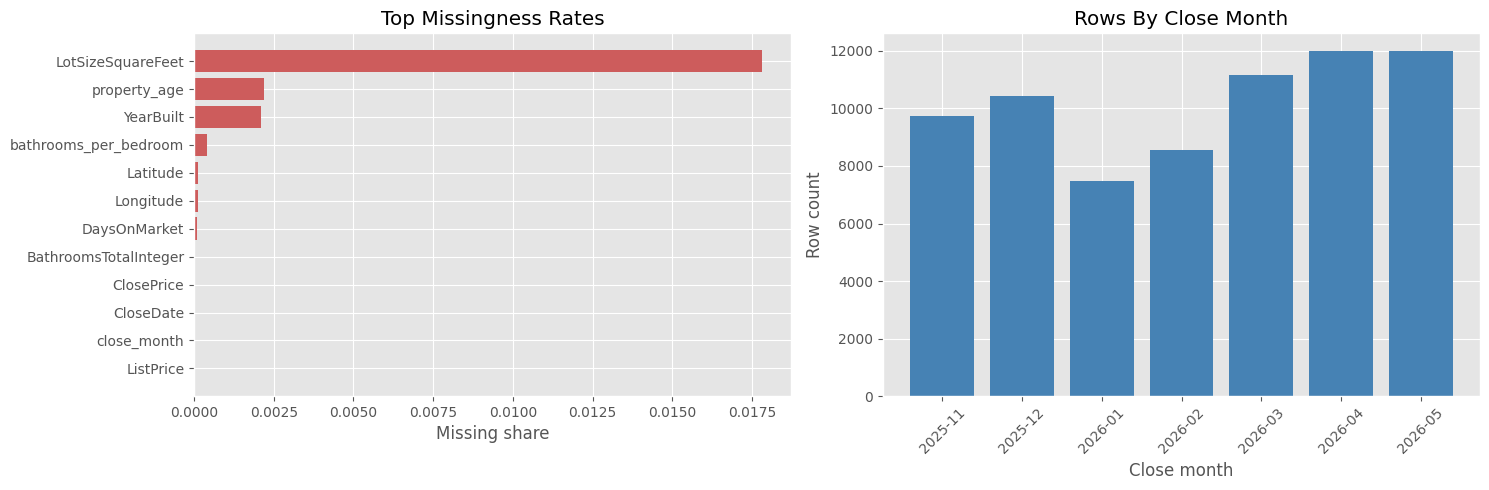

In [5]:
missing_summary = (
    model_df.isna()
    .mean()
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values("missing_pct", ascending=False)
)

display(missing_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(
    missing_summary["column"].head(12)[::-1],
    missing_summary["missing_pct"].head(12)[::-1],
    color="indianred",
)
axes[0].set_title("Top Missingness Rates")
axes[0].set_xlabel("Missing share")

monthly_rows = (
    model_df.groupby("close_month")
    .size()
    .rename("row_count")
    .reset_index()
    .sort_values("close_month")
)
axes[1].bar(
    monthly_rows["close_month"].dt.strftime("%Y-%m"),
    monthly_rows["row_count"],
    color="steelblue",
)
axes[1].set_title("Rows By Close Month")
axes[1].set_xlabel("Close month")
axes[1].set_ylabel("Row count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Time-Based Split

Per the assignment, the most recent available month is used as the test set. The preceding months are used as the training set. Here we keep the training window simple and use the prior 6 months if available.


In [6]:
available_months = sorted(model_df["close_month"].dropna().unique())
if len(available_months) < 2:
    raise ValueError("Need at least two close months to build train/test split")

test_month = available_months[-1]
train_window_months = min(6, len(available_months) - 1)
train_months = available_months[-(train_window_months + 1) : -1]

train_df = model_df.loc[model_df["close_month"].isin(train_months)].copy()
test_df = model_df.loc[model_df["close_month"] == test_month].copy()

print(f"Train months: {[m.strftime('%Y-%m') for m in train_months]}")
print(f"Test month: {test_month.strftime('%Y-%m')}")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")


Train months: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
Test month: 2026-05
Train rows: 59,345
Test rows: 12,007


,dataset,rows,close_price_median,living_area_median
0,train,59345,880000.00,1819.00
1,test,12007,930000.00,1854.00


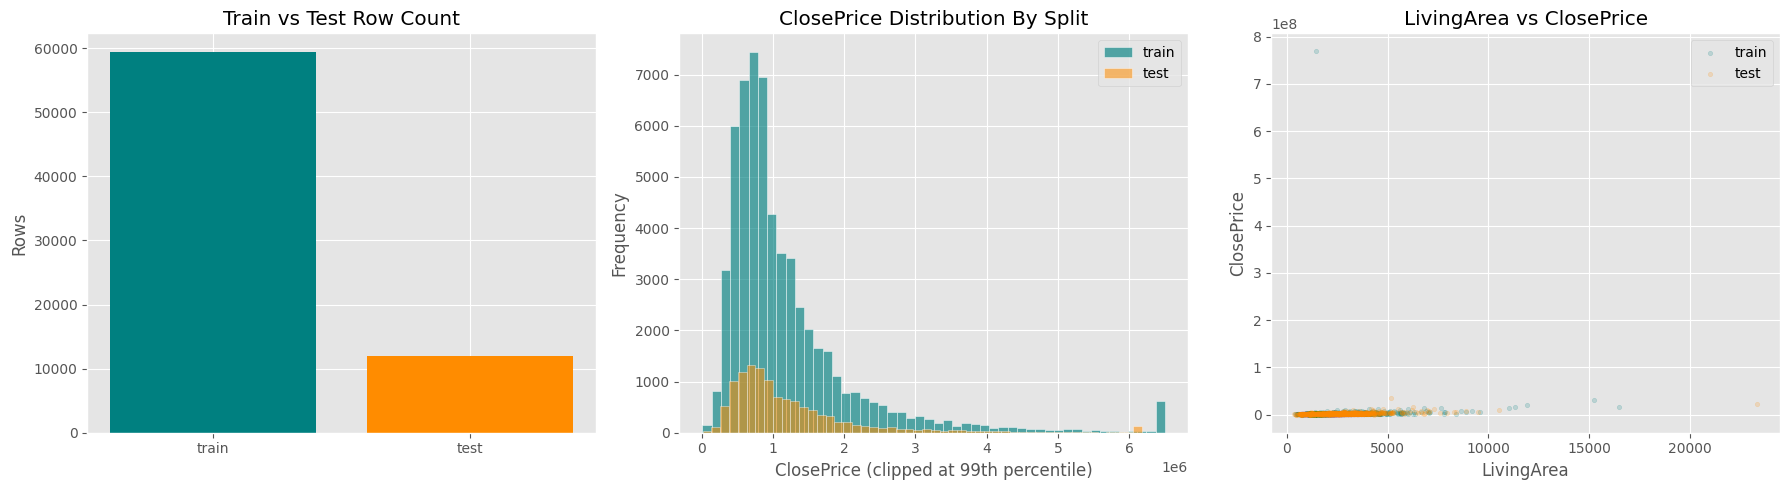

In [7]:
split_summary = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "close_price_median": [
            train_df["ClosePrice"].median(),
            test_df["ClosePrice"].median(),
        ],
        "living_area_median": [
            train_df["LivingArea"].median(),
            test_df["LivingArea"].median(),
        ],
    }
)
display(split_summary)

sample_train = train_df.sample(min(3000, len(train_df)), random_state=42)
sample_test = test_df.sample(min(3000, len(test_df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(
    split_summary["dataset"], split_summary["rows"], color=["teal", "darkorange"]
)
axes[0].set_title("Train vs Test Row Count")
axes[0].set_ylabel("Rows")

train_df["ClosePrice"].clip(upper=train_df["ClosePrice"].quantile(0.99)).plot(
    kind="hist",
    bins=50,
    alpha=0.65,
    ax=axes[1],
    label="train",
    color="teal",
    edgecolor="white",
)
test_df["ClosePrice"].clip(upper=test_df["ClosePrice"].quantile(0.99)).plot(
    kind="hist",
    bins=50,
    alpha=0.55,
    ax=axes[1],
    label="test",
    color="darkorange",
    edgecolor="white",
)
axes[1].set_title("ClosePrice Distribution By Split")
axes[1].set_xlabel("ClosePrice (clipped at 99th percentile)")
axes[1].legend()

axes[2].scatter(
    sample_train["LivingArea"],
    sample_train["ClosePrice"],
    alpha=0.18,
    s=10,
    color="teal",
    label="train",
)
axes[2].scatter(
    sample_test["LivingArea"],
    sample_test["ClosePrice"],
    alpha=0.18,
    s=10,
    color="darkorange",
    label="test",
)
axes[2].set_title("LivingArea vs ClosePrice")
axes[2].set_xlabel("LivingArea")
axes[2].set_ylabel("ClosePrice")
axes[2].legend()

plt.tight_layout()
plt.show()


In [8]:
train_output = processed_dir / "train_preprocessed.csv"
test_output = processed_dir / "test_preprocessed.csv"
full_output = processed_dir / "full_preprocessed_week3.csv"

train_df.to_csv(train_output, index=False)
test_df.to_csv(test_output, index=False)
model_df.to_csv(full_output, index=False)

print(f"Saved train set to {train_output}")
print(f"Saved test set to {test_output}")
print(f"Saved full cleaned dataset to {full_output}")


Saved train set to ../data/processed/train_preprocessed.csv
Saved test set to ../data/processed/test_preprocessed.csv
Saved full cleaned dataset to ../data/processed/full_preprocessed_week3.csv
